### ENTREGABLE VI EMPRESA ALIADA
OBJETIVO
- Construir, validar y optimizar un modelo de series de tiempo para pronosticar las ventas totales semanales de la empresa

In [1]:
# IMPORTAR LIBRERIAS
from pathlib import Path
from itertools import product
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


In [2]:
# CARGAR Y PREPARAR LOS DATOS 
carpeta_proyecto = Path.cwd()
ruta_datos = carpeta_proyecto / "datos_procesados" / "VENTAS_CON_CALENDARIO.csv"

ventas_detalle = pd.read_csv(ruta_datos)

print("Archivo cargado correctamente.")
print("Dimensiones:", ventas_detalle.shape)

display(ventas_detalle.head())
print("\nColumnas disponibles:")
print(ventas_detalle.columns.tolist())


Archivo cargado correctamente.
Dimensiones: (122002, 10)


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,MONTH,WEEK_NUMBER,DATE
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28 00:00:00
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28 00:00:00
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28 00:00:00
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28 00:00:00
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28 00:00:00



Columnas disponibles:
['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION', 'YEAR', 'MONTH', 'WEEK_NUMBER', 'DATE']


In [3]:
# VALIDAR Y CONSTRUIR LA SERIE SEMANAL
columnas_necesarias = {"DATE", "TOTAL_VALUE_SALES"}
columnas_faltantes = columnas_necesarias - set(ventas_detalle.columns)

if columnas_faltantes:
    raise ValueError(f"Faltan estas columnas en el archivo: {columnas_faltantes}")

ventas_detalle["DATE"] = pd.to_datetime(
    ventas_detalle["DATE"],
    dayfirst=True,
    errors="coerce"
)

ventas_detalle["TOTAL_VALUE_SALES"] = pd.to_numeric(
    ventas_detalle["TOTAL_VALUE_SALES"],
    errors="coerce"
)

ventas_detalle = ventas_detalle.dropna(
    subset=["DATE", "TOTAL_VALUE_SALES"]
).copy()

# Consolidar la venta total por semana
ventas_semanales = (
    ventas_detalle
    .groupby("DATE")["TOTAL_VALUE_SALES"]
    .sum()
    .sort_index()
)

# Reindexar a frecuencia semanal completa (esto genera NaN reales
# en las semanas sin ningún registro, ANTES de rellenar nada)
ventas_semanales = ventas_semanales.asfreq("W-SUN")

# --- CORRECCIÓN CLAVE ---
# Detectar la última semana con dato real ANTES de rellenar.
# Las semanas sin registro AL FINAL de la serie casi siempre significan
# "todavía no hay datos capturados", no "se vendió cero".
ultima_semana_real = ventas_semanales.last_valid_index()

if ultima_semana_real is None:
    raise ValueError("No hay ninguna semana con datos reales en la serie.")

semanas_descartadas = ventas_semanales.loc[ultima_semana_real:].index[1:]
print(f"Última semana con datos reales: {ultima_semana_real.date()}")
print(f"Semanas finales descartadas por no tener información: {len(semanas_descartadas)}")

# Cortamos la serie hasta la última semana con dato real
ventas_semanales = ventas_semanales.loc[:ultima_semana_real]

# Ahora sí: los huecos INTERNOS (rodeados de datos reales) se
# interpretan como semanas de venta genuinamente baja/nula
huecos_internos = ventas_semanales.isna().sum()
print(f"Huecos internos rellenados con 0: {huecos_internos}")

ventas_semanales = ventas_semanales.fillna(0)
ventas_semanales.name = "TOTAL_VALUE_SALES"

print(f"Periodo final de análisis: {ventas_semanales.index.min().date()} a {ventas_semanales.index.max().date()}")
print(f"Número de semanas: {len(ventas_semanales)}")

display(ventas_semanales.head())
display(ventas_semanales.tail())

Última semana con datos reales: 2023-01-01
Semanas finales descartadas por no tener información: 28
Huecos internos rellenados con 0: 0
Periodo final de análisis: 2022-01-09 a 2023-01-01
Número de semanas: 52


DATE
2022-01-09    151538.922
2022-01-16    146996.991
2022-01-23    125351.336
2022-01-30    123945.617
2022-02-06    129841.767
Freq: W-SUN, Name: TOTAL_VALUE_SALES, dtype: float64

DATE
2022-12-04    141513.394
2022-12-11    125880.501
2022-12-18    133458.685
2022-12-25    120253.571
2023-01-01    130607.842
Freq: W-SUN, Name: TOTAL_VALUE_SALES, dtype: float64

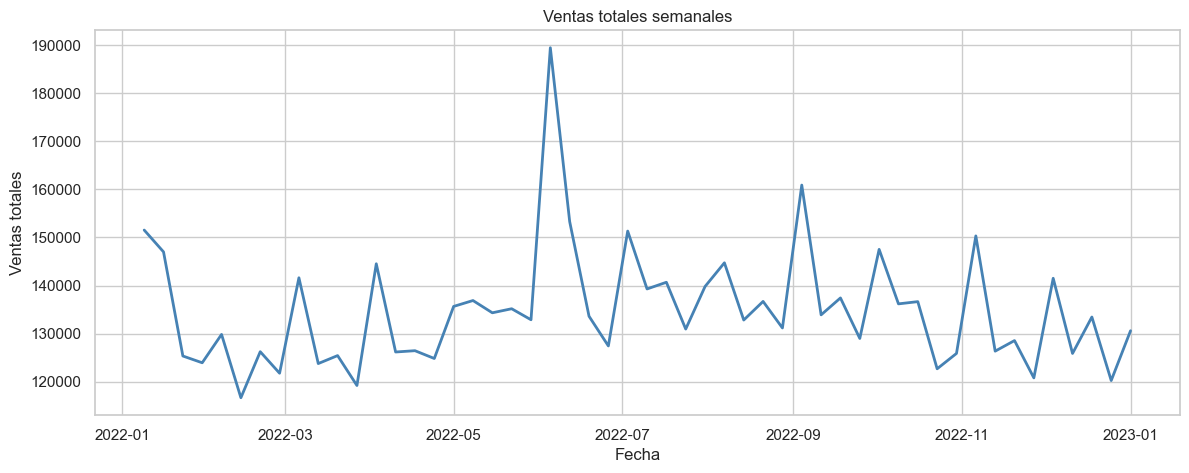

In [4]:
# EXPLORAR EL COMPORTAMIENTO DE LAS VENTAS
plt.figure(figsize=(14, 5))

plt.plot(
    ventas_semanales.index,
    ventas_semanales.values,
    color="steelblue",
    linewidth=2
)

plt.title("Ventas totales semanales")
plt.xlabel("Fecha")
plt.ylabel("Ventas totales")
plt.show()

In [5]:
resultado_adf = adfuller(ventas_semanales)

print("Prueba de estacionariedad Dickey-Fuller aumentada")
print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"p-value: {resultado_adf[1]:.4f}")

if resultado_adf[1] < 0.05:
    print("\nLa serie parece estacionaria.")
else:
    print("\nLa serie no parece estacionaria; se probará diferenciación dentro de ARIMA.")

Prueba de estacionariedad Dickey-Fuller aumentada
Estadístico ADF: -2.0760
p-value: 0.2543

La serie no parece estacionaria; se probará diferenciación dentro de ARIMA.


JUSTIFICACION DEL MODELO

Se utilizará un modelo ARIMA porque la variable objetivo corresponde a ventas observadas a lo largo del tiempo y se busca realizar pronósticos futuros. 

No se empleará una regresión con `TOTAL_UNIT_SALES` o `TOTAL_UNIT_AVG_WEEKLY_SALES`, ya que esas variables se conocen durante la misma semana de venta y no estarían disponibles al momento de realizar un pronóstico futuro. 

Tampoco se aplicará inicialmente SARIMA con estacionalidad anual de 52 semanas, debido a que el historial disponible no contiene suficientes ciclos anuales completos para estimarla de manera confiable.

In [6]:
# DIVIDIR LOS DATOS DE ENTRENAMIENTO Y PRUEBA
HORIZONTE_PRUEBA = 8

if len(ventas_semanales) <= HORIZONTE_PRUEBA + 12:
    raise ValueError(
        "No hay suficientes semanas para realizar la división temporal. "
        "Reduce HORIZONTE_PRUEBA."
    )

train = ventas_semanales.iloc[:-HORIZONTE_PRUEBA]
test = ventas_semanales.iloc[-HORIZONTE_PRUEBA:]

print("Periodo de entrenamiento:")
print(f"{train.index.min().date()} a {train.index.max().date()}")

print("\nPeriodo de prueba:")
print(f"{test.index.min().date()} a {test.index.max().date()}")

# Modelo de referencia: repite la última venta conocida
prediccion_base = pd.Series(
    train.iloc[-1],
    index=test.index,
    name="Prediccion_base"
)

Periodo de entrenamiento:
2022-01-09 a 2022-11-06

Periodo de prueba:
2022-11-13 a 2023-01-01


In [7]:
# BUSCAR LOS MEJORES PARAMETROS ARIMA
valores_p = range(0, 4)
valores_d = range(0, 2)
valores_q = range(0, 4)

resultados_aic = []

for p, d, q in product(valores_p, valores_d, valores_q):
    try:
        modelo = SARIMAX(
            train,
            order=(p, d, q),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        ajuste = modelo.fit(disp=False)

        resultados_aic.append({
            "Orden ARIMA": (p, d, q),
            "AIC": ajuste.aic,
            "BIC": ajuste.bic
        })

    except Exception:
        pass

tabla_aic = (
    pd.DataFrame(resultados_aic)
    .sort_values("AIC")
    .reset_index(drop=True)
)

display(tabla_aic.head(10))

mejor_orden = tabla_aic.loc[0, "Orden ARIMA"]
print(f"Mejor modelo según AIC: ARIMA{mejor_orden}")

,Orden ARIMA,AIC,BIC
0,"(3, 1, 3)",856.217378,867.862309
1,"(1, 1, 3)",859.105706,867.423515
2,"(2, 1, 3)",860.805936,870.787306
3,"(0, 1, 3)",860.866447,867.520693
4,"(3, 1, 0)",873.775594,880.531111
5,"(3, 1, 1)",874.324894,882.769292
6,"(3, 1, 2)",874.985747,885.119023
7,"(2, 1, 2)",878.153791,886.598189
8,"(1, 1, 2)",878.315618,885.071136
9,"(0, 1, 2)",880.052914,885.119552


Mejor modelo según AIC: ARIMA(3, 1, 3)


In [8]:
# ENTRENAR Y VALIDAR EL MODELO
modelo_arima = SARIMAX(
    train,
    order=mejor_orden,
    enforce_stationarity=False,
    enforce_invertibility=False
)

ajuste_arima = modelo_arima.fit(disp=False)

prediccion_arima = ajuste_arima.get_forecast(
    steps=len(test)
).predicted_mean

# Las ventas no pueden ser negativas
prediccion_arima = prediccion_arima.clip(lower=0)
prediccion_arima.index = test.index

In [9]:
def calcular_metricas(valores_reales, valores_predichos):
    mse = mean_squared_error(valores_reales, valores_predichos)
    mae = mean_absolute_error(valores_reales, valores_predichos)

    mascara_no_cero = valores_reales != 0

    if mascara_no_cero.sum() > 0:
        mape = (
            np.mean(
                np.abs(
                    (valores_reales[mascara_no_cero] -
                     valores_predichos[mascara_no_cero]) /
                    valores_reales[mascara_no_cero]
                )
            ) * 100
        )
    else:
        mape = np.nan

    return mse, mae, mape

mse_base, mae_base, mape_base = calcular_metricas(test, prediccion_base)
mse_arima, mae_arima, mape_arima = calcular_metricas(test, prediccion_arima)

comparacion_modelos = pd.DataFrame({
    "Modelo": ["Modelo base", f"ARIMA{mejor_orden}"],
    "MSE": [mse_base, mse_arima],
    "MAE": [mae_base, mae_arima],
    "MAPE (%)": [mape_base, mape_arima]
})

display(comparacion_modelos.round(2))

,Modelo,MSE,MAE,MAPE (%)
0,Modelo base,5.213166e+08,21890.52,17.34
1,"ARIMA(3, 1, 3)",8.417053e+07,7948.11,6.33


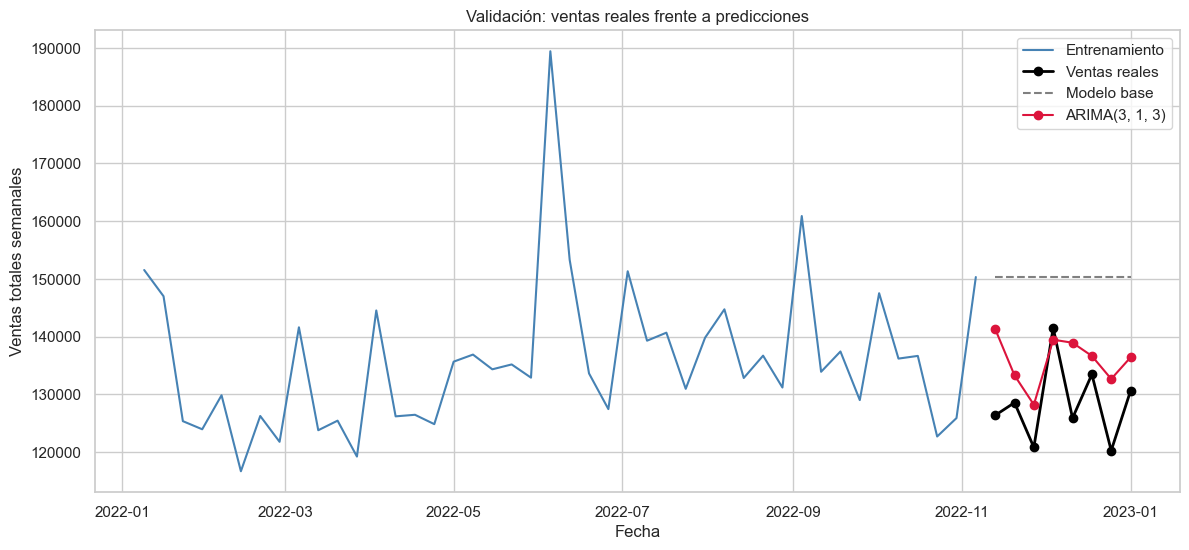

In [10]:
# GRAFICO DE VALORES REALES
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train.values,
    label="Entrenamiento",
    color="steelblue"
)

plt.plot(
    test.index,
    test.values,
    label="Ventas reales",
    color="black",
    marker="o",
    linewidth=2
)

plt.plot(
    prediccion_base.index,
    prediccion_base.values,
    label="Modelo base",
    color="gray",
    linestyle="--"
)

plt.plot(
    prediccion_arima.index,
    prediccion_arima.values,
    label=f"ARIMA{mejor_orden}",
    color="crimson",
    marker="o"
)

plt.title("Validación: ventas reales frente a predicciones")
plt.xlabel("Fecha")
plt.ylabel("Ventas totales semanales")
plt.legend()
plt.show()

In [11]:
# ELEGIR EL MODELO FINAL Y GENERAR PREDICCIONES FUTURAS
HORIZONTE_FUTURO = 12

if mae_arima <= mae_base:
    modelo_ganador = f"ARIMA{mejor_orden}"

    modelo_produccion = SARIMAX(
        ventas_semanales,
        order=mejor_orden,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    ajuste_produccion = modelo_produccion.fit(disp=False)

    pronostico_futuro = ajuste_produccion.get_forecast(
        steps=HORIZONTE_FUTURO
    ).predicted_mean.clip(lower=0)

else:
    modelo_ganador = "Modelo base"

    fechas_futuras = pd.date_range(
        start=ventas_semanales.index.max() + pd.Timedelta(weeks=1),
        periods=HORIZONTE_FUTURO,
        freq="W-SUN"
    )

    pronostico_futuro = pd.Series(
        ventas_semanales.iloc[-1],
        index=fechas_futuras
    )

pronostico_futuro.name = "VENTAS_PRONOSTICADAS"

print(f"Modelo seleccionado para el pronóstico final: {modelo_ganador}")

tabla_pronostico = pd.DataFrame({
    "Fecha": pronostico_futuro.index,
    "Ventas pronosticadas": pronostico_futuro.values
})

display(tabla_pronostico.round(2))

Modelo seleccionado para el pronóstico final: ARIMA(3, 1, 3)


,Fecha,Ventas pronosticadas
0,2023-01-08,127377.30
1,2023-01-15,132199.49
2,2023-01-22,125866.06
3,2023-01-29,129282.45
4,2023-02-05,127698.33
5,2023-02-12,130287.44
6,2023-02-19,127632.21
7,2023-02-26,128903.54
8,2023-03-05,128055.03
9,2023-03-12,129339.68


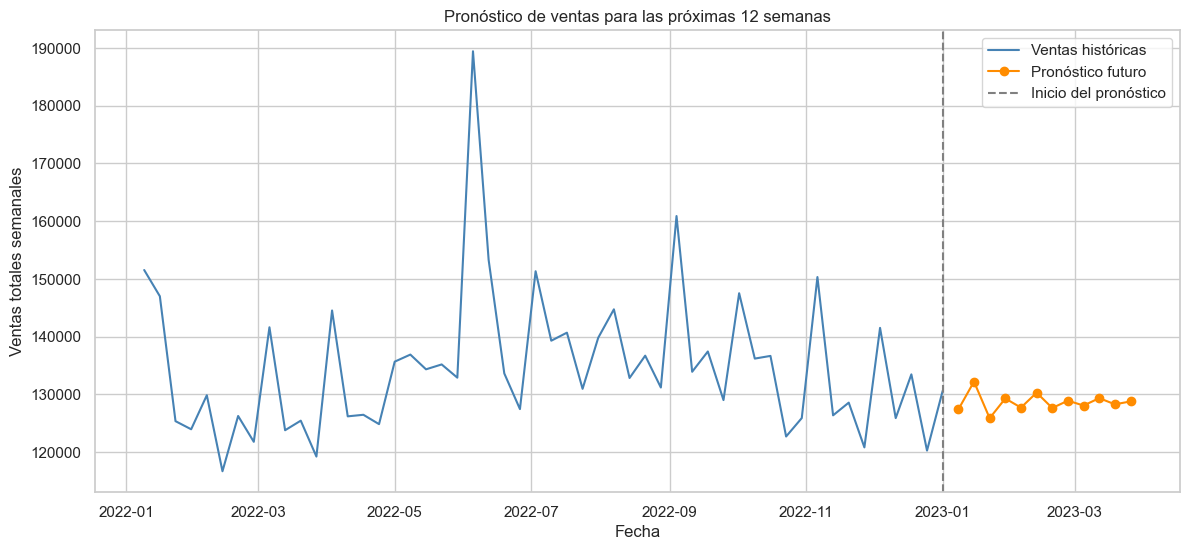

In [12]:
# GRAFICO Y TABLA MENSUAL DEL PRONOSTICO
plt.figure(figsize=(14, 6))

plt.plot(
    ventas_semanales.index,
    ventas_semanales.values,
    label="Ventas históricas",
    color="steelblue"
)

plt.plot(
    pronostico_futuro.index,
    pronostico_futuro.values,
    label="Pronóstico futuro",
    color="darkorange",
    marker="o"
)

plt.axvline(
    ventas_semanales.index.max(),
    color="gray",
    linestyle="--",
    label="Inicio del pronóstico"
)

plt.title("Pronóstico de ventas para las próximas 12 semanas")
plt.xlabel("Fecha")
plt.ylabel("Ventas totales semanales")
plt.legend()
plt.show()

In [13]:
pronostico_mensual = (
    pronostico_futuro
    .resample("MS")
    .sum()
    .reset_index()
)

pronostico_mensual.columns = [
    "Mes",
    "Ventas pronosticadas del mes"
]

display(pronostico_mensual.round(2))

,Mes,Ventas pronosticadas del mes
0,2023-01-01,514725.30
1,2023-02-01,514521.52
2,2023-03-01,514434.39


In [14]:
print(f"""
CONCLUSIONES DEL MODELO

La variable objetivo fue TOTAL_VALUE_SALES, agregada a nivel semanal.

Se evaluó un modelo ARIMA para pronosticar las ventas futuras. El mejor
orden identificado mediante el criterio AIC fue ARIMA{mejor_orden}.

Durante la validación temporal, el modelo ARIMA obtuvo:
- MSE: {mse_arima:,.2f}
- MAE: {mae_arima:,.2f}
- MAPE: {mape_arima:.2f}%

El modelo final seleccionado fue: {modelo_ganador}.

Se generó un pronóstico para las próximas {HORIZONTE_FUTURO} semanas,
el cual se guardó en los archivos PRONOSTICO_VENTAS_12_SEMANAS.csv y
PRONOSTICO_VENTAS_MENSUALES.csv.
""")


CONCLUSIONES DEL MODELO

La variable objetivo fue TOTAL_VALUE_SALES, agregada a nivel semanal.

Se evaluó un modelo ARIMA para pronosticar las ventas futuras. El mejor
orden identificado mediante el criterio AIC fue ARIMA(3, 1, 3).

Durante la validación temporal, el modelo ARIMA obtuvo:
- MSE: 84,170,533.04
- MAE: 7,948.11
- MAPE: 6.33%

El modelo final seleccionado fue: ARIMA(3, 1, 3).

Se generó un pronóstico para las próximas 12 semanas,
el cual se guardó en los archivos PRONOSTICO_VENTAS_12_SEMANAS.csv y
PRONOSTICO_VENTAS_MENSUALES.csv.

